# Net-Payout-Based Duration

## 0. Setup, Imports, Paths, Session


In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from pathlib import Path
from plot_style import COLORS, set_global_plot_style, style_axes

set_global_plot_style()

# Speicherstruktur fuer Intermediate und Final Output
from project_paths import BASE_DIR, DATA_DIR, CACHE_DATA_DIR

def save_parquet(df: pd.DataFrame, name: str):
    path = DATA_DIR / f"{name}.parquet"
    df.to_parquet(path, index=False)
    print(f"Saved: {path}")

def load_parquet(name: str) -> pd.DataFrame:
    path = DATA_DIR / f"{name}.parquet"
    return pd.read_parquet(path)


## 2. Master Panel Construction


In [2]:
# Load annual duration input table (full-history saved as euro500_netpayout)
duration_input = load_parquet("euro500_netpayout").copy()

if "firm_id" not in duration_input.columns:
    raise KeyError("euro500_netpayout must contain firm_id")

# Ensure Module D field is present already at Step 1 input stage.
if "CashSTInvst" not in duration_input.columns:
    duration_input["CashSTInvst"] = np.nan

# Derive year from the annual observation date (fallback: effective_date)
if "date" in duration_input.columns:
    duration_input["date"] = pd.to_datetime(duration_input["date"], errors="coerce")
    duration_input["year"] = duration_input["date"].dt.year
elif "effective_date" in duration_input.columns:
    duration_input["effective_date"] = pd.to_datetime(duration_input["effective_date"], errors="coerce")
    duration_input["year"] = duration_input["effective_date"].dt.year
elif "year" not in duration_input.columns:
    raise KeyError("euro500_netpayout needs date, effective_date, or year")

# Quarterly EURO500 panel is only the mapping target for final output.
base_euro500 = load_parquet("euro500").copy()
if "firm_id" not in base_euro500.columns:
    raise KeyError("euro500 must contain firm_id")

euro500_netpayout = duration_input.copy()

print(
    f"Loaded annual duration input (euro500_netpayout): rows={len(duration_input):,}, "
    f"firm_id={duration_input['firm_id'].nunique():,}"
)
print(
    f"Loaded quarterly mapping base (euro500): rows={len(base_euro500):,}, "
    f"firm_id={base_euro500['firm_id'].nunique():,}"
)
print("Step 1 check: CashSTInvst in duration input =", "CashSTInvst" in duration_input.columns)


Loaded annual duration input (euro500_netpayout): rows=16,872, firm_id=1,125
Loaded quarterly mapping base (euro500): rows=56,500, firm_id=1,248
Step 1 check: CashSTInvst in duration input = True


### 2.1 Firm-Year Master Panel (ME, BE, Assets, Sales, NI, GP, Debt, Dividends, Buybacks, CashSTInvst)


In [3]:

def build_masterpanel_firmyear(euro500_netpayout):
    """
    Build one row per firm_id-year for valuation/state construction.
    Keeps firm metadata (name) and accounting/value fields.
    """
    df = euro500_netpayout.copy()

    df["firm_id"] = df["firm_id"].astype(str).str.strip()
    df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
    df = df.dropna(subset=["firm_id", "year"]).copy()
    df["year"] = df["year"].astype(int)

    for dt_col in ["date", "effective_date"]:
        if dt_col in df.columns:
            df[dt_col] = pd.to_datetime(df[dt_col], errors="coerce")

    rename_map = {
        "mcap_eur": "ME",
        "Sales": "sales",
        "NetIncome": "net_income",
        "GrossProfit": "gross_profit",
        "Dividends": "dividends",
        "Buybacks": "buybacks",
    }
    existing_renames = {k: v for k, v in rename_map.items() if k in df.columns}
    if existing_renames:
        df = df.rename(columns=existing_renames)

    cols = [
        "firm_id", "name", "year", "date", "effective_date",
        "ME", "BE", "assets", "sales", "net_income", "gross_profit", "debt",
        "dividends", "buybacks", "CashSTInvst",
        # Mögliche Emissionsspalten (für Netto-Payout, Paper S. 7, Fn. 6)
        "issuances", "equity_issuances", "share_issuances",
    ]
    cols = [c for c in cols if c in df.columns]
    df = df[cols].copy()

    value_cols = [
        c for c in [
            "ME", "BE", "assets", "sales", "net_income", "gross_profit", "debt",
            "dividends", "buybacks", "CashSTInvst",
            "issuances", "equity_issuances", "share_issuances",
        ] if c in df.columns
    ]
    for c in value_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # one row per firm-year from annual input: prefer year-end observation (latest date in year)
    dedupe_date_cols = [c for c in ["date", "effective_date"] if c in df.columns]
    sort_cols = ["firm_id", "year"] + dedupe_date_cols
    df = df.sort_values(sort_cols)
    df = df.drop_duplicates(subset=["firm_id", "year"], keep="last").reset_index(drop=True)

    df["dividends"] = df["dividends"].fillna(0.0) if "dividends" in df.columns else 0.0
    df["buybacks"]  = df["buybacks"].fillna(0.0)  if "buybacks"  in df.columns else 0.0

    # ============================================================
    # Netto-Payout: PO = Dividenden + Net Equity Repurchases
    # Paper S. 7, Fn. 6: PO = Cash Dividends + Net Equity Repurchases
    #   Net Equity Repurchases = Buybacks – Issuances (+ Preferred adjustments)
    # Paper S. 7: "the net payout in any given fiscal year is equal to
    #   cash dividends (dvc) + net equity repurchases"
    # ============================================================
    issuances_col = None
    for candidate in ["issuances", "equity_issuances", "share_issuances"]:
        if candidate in df.columns:
            issuances_col = candidate
            break

    if issuances_col is not None:
        df[issuances_col] = df[issuances_col].fillna(0.0)
        df["PO"] = df["dividends"] + df["buybacks"] - df[issuances_col]
        # Net payout kann nicht negativ sein (Paper: firms distribute resources)
        df["PO"] = df["PO"].clip(lower=0)
        print(f"PO = dividends + buybacks - {issuances_col}  (paper-konform, Fn. 6)")
    else:
        # NOTE: Abweichung vom Paper: Emissionen fehlen in den Rohdaten.
        # Dies führt zu einer systematischen Überschätzung von PO bei
        # wachstumsstarken Firmen (die viele neue Aktien ausgeben).
        # Paper Fn. 6: PO sollte Net Equity Repurchases = Buybacks - Issuances enthalten.
        df["PO"] = df["dividends"] + df["buybacks"]
        print("NOTE: Abweichung vom Paper – keine Emissionsspalte gefunden.")
        print("PO = dividends + buybacks (Issuances fehlen → Überschätzung bei Wachstumsfirmen)")

    df = df.sort_values(["firm_id", "year"]).reset_index(drop=True)
    lag_vars = [
        c for c in ["ME", "BE", "assets", "sales", "net_income", "gross_profit",
                    "debt", "dividends", "buybacks", "CashSTInvst", "PO"]
        if c in df.columns
    ]
    for c in lag_vars:
        df[f"{c}_lag1"] = df.groupby("firm_id")[c].shift(1)

    df["dBE"]      = df["BE"] - df["BE_lag1"]
    df["avgBE"]    = 0.5 * (df["BE"] + df["BE_lag1"])
    df["avgAssets"] = 0.5 * (df["assets"] + df["assets_lag1"])

    df.loc[df["ME"] <= 0, "ME"]         = pd.NA
    df.loc[df["BE"] <= 0, "BE"]         = pd.NA
    df.loc[df["assets"] <= 0, "assets"] = pd.NA
    df.loc[df["sales"] <= 0, "sales"]   = pd.NA
    df.loc[df["debt"] < 0, "debt"]      = pd.NA

    return df


In [4]:
master = build_masterpanel_firmyear(euro500_netpayout)

master.head()

NOTE: Abweichung vom Paper – keine Emissionsspalte gefunden.
PO = dividends + buybacks (Issuances fehlen → Überschätzung bei Wachstumsfirmen)


,firm_id,year,date,ME,BE,assets,sales,net_income,gross_profit,debt,...,net_income_lag1,gross_profit_lag1,debt_lag1,dividends_lag1,buybacks_lag1,CashSTInvst_lag1,PO_lag1,dBE,avgBE,avgAssets
0,FIRM0000001,1998,1998-11-30,138569059.780975,92670119.59117,201941375.2729,296097820.36271,15384772.70519,145027942.10131,54100816.53313,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,FIRM0000001,1999,1999-11-30,121992375.0,104237075.81947,264407949.56617,305313856.52127,15307056.33925,148917850.73345,101319133.05349,...,15384772.70519,145027942.10131,54100816.53313,10021320.87145,0.0,20117801.64943,10021320.87145,11566956.2283,98453597.70532,233174662.419535
2,FIRM0000001,2000,2000-11-30,192793449.999999,108772234.80568,265103817.81648,379503331.06661,14892398.6236,184504276.95659,99152278.06098,...,15307056.33925,148917850.73345,101319133.05349,0.0,0.0,39481959.06597,0.0,4535158.98621,106504655.312575,264755883.691325
3,FIRM0000001,2001,2001-11-30,176409250.0,108458000.0,259187000.0,379731000.0,12857000.0,183741000.0,94053000.0,...,14892398.6236,184504276.95659,99152278.06098,11046972.38513,0.0,21139362.82806,11046972.38513,-314234.80568,108615117.40284,262145408.90824
4,FIRM0000001,2002,2002-11-30,162393850.0,107209000.0,251266000.0,350488000.0,12126000.0,173302000.0,86852000.0,...,12857000.0,183741000.0,94053000.0,11888000.0,0.0,28166000.0,11888000.0,-1249000.0,107833500.0,255226500.0


## 3. Data Validity Checks

Before constructing state variables, this section checks whether all denominator and transformation conditions are valid (e.g., positivity for log terms and `1+x>0` for `log1p`).

Potential violations are rare, so only a small share of observations is excluded through the `safe_log` / `safe_log1p` guards.


In [5]:
checks = pd.DataFrame({
    
    # valuation
    "ME<=0": (master["ME"] <= 0),
    "BE<=0": (master["BE"] <= 0),
    "sales<=0": (master["sales"] <= 0),
    
    # growth
    "BE_lag1<=0": (master["BE_lag1"] <= 0),
    "assets_lag1<=0": (master["assets_lag1"] <= 0),
    "sales_lag1<=0": (master["sales_lag1"] <= 0),

    # profitability denominators
    "avgBE<=0": (master["avgBE"] <= 0),
    "avgAssets<=0": (master["avgAssets"] <= 0),

    # log1p conditions
    "1+PO/ME<=0": (1 + master["PO"]/master["ME"] <= 0),
    "1+(PO+dBE)/BE_lag1<=0": (1 + (master["PO"] + master["dBE"]) / master["BE_lag1"] <= 0),
    "1+NI/avgBE<=0": (1 + master["net_income"] / master["avgBE"] <= 0),
    "1+GP/avgAssets<=0": (1 + master["gross_profit"] / master["avgAssets"] <= 0),

    # leverage denominator
    "debt+ME<=0": (master["debt"] + master["ME"] <= 0),
})

checks.mean().sort_values(ascending=False)

BE_lag1<=0               0.008898
avgBE<=0                 0.007264
1+(PO+dBE)/BE_lag1<=0    0.007199
1+NI/avgBE<=0            0.005696
sales_lag1<=0            0.003243
1+PO/ME<=0               0.001585
1+GP/avgAssets<=0        0.000221
ME<=0                         0.0
BE<=0                         0.0
sales<=0                      0.0
assets_lag1<=0                0.0
avgAssets<=0                  0.0
debt+ME<=0                    0.0
dtype: Float64

## 4. Construction of Firm-Level State Variables


In this step, we construct the firm-level state variables used in the pooled VAR(1).

The state vector contains exactly 12 variables:
- `bm`, `py`, `sy`, `beg`, `ag`, `sg`, `csprof`, `roe`, `gp`, `lev`, `blev`, `cash`

The clean-surplus profitability definition is:
$$
csprof_{i,t} = \log\left(1 + \frac{PO_{i,t} + \Delta BE_{i,t}}{BE_{i,t-1}}\right).
$$

At this stage, variables are constructed from raw accounting/market inputs; winsorization is applied in Step 4.


In [6]:
def build_state_variables(master):
    df = master.copy()

    def safe_log(x):
        x = pd.to_numeric(x, errors="coerce")
        out = pd.Series(np.nan, index=df.index, dtype=float)
        m = x > 0
        out.loc[m] = np.log(x.loc[m])
        return out

    def safe_log1p(x):
        x = pd.to_numeric(x, errors="coerce")
        out = pd.Series(np.nan, index=df.index, dtype=float)
        m = x > -1  # log(1+x) defined iff 1+x > 0
        out.loc[m] = np.log1p(x.loc[m])
        return out

    # Ensure numeric inputs
    num_cols = [
        "BE", "ME", "PO", "sales",
        "BE_lag1", "assets", "assets_lag1", "sales_lag1",
        "dBE", "net_income", "avgBE", "gross_profit", "avgAssets",
        "debt", "CashSTInvst"
    ]
    for col in num_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # Valuation
    df["bm"] = safe_log(df["BE"] / df["ME"])
    df["py"] = safe_log1p(df["PO"] / df["ME"])
    df["sy"] = safe_log(df["sales"] / df["ME"])

    # Growth
    df["beg"] = safe_log(df["BE"] / df["BE_lag1"])
    df["ag"]  = safe_log(df["assets"] / df["assets_lag1"])
    df["sg"]  = safe_log(df["sales"] / df["sales_lag1"])

    # Profitability
    csprof_raw = (df["PO"] + df["dBE"]) / df["BE_lag1"]
    roe_raw    = df["net_income"] / df["avgBE"]
    gp_raw     = df["gross_profit"] / df["avgAssets"]

    # Optional paper-near floor so log1p stays well-defined
    csprof_raw = csprof_raw.clip(lower=-0.99)
    roe_raw    = roe_raw.clip(lower=-0.99)
    gp_raw     = gp_raw.clip(lower=-0.99)

    df["csprof"] = safe_log1p(csprof_raw)
    df["roe"]    = safe_log1p(roe_raw)
    df["gp"]     = safe_log1p(gp_raw)

    # Capital structure: book leverage and cash holdings
    assets = df["assets"].to_numpy(dtype=float)
    debt   = df["debt"].to_numpy(dtype=float)
    cash   = df["CashSTInvst"].to_numpy(dtype=float)
    me     = df["ME"].to_numpy(dtype=float)

    blev = np.full(len(df), np.nan, dtype=float)
    cash_ratio = np.full(len(df), np.nan, dtype=float)

    mask_assets = assets > 0
    blev[mask_assets] = debt[mask_assets] / assets[mask_assets]
    cash_ratio[mask_assets] = cash[mask_assets] / assets[mask_assets]

    df["blev"] = blev
    df["cash"] = cash_ratio

    # Capital structure: market leverage
    denom = debt + me
    lev = np.full(len(df), np.nan, dtype=float)
    mask_lev = denom > 0
    lev[mask_lev] = debt[mask_lev] / denom[mask_lev]
    df["lev"] = lev

    # Final state variable set
    state_vars = [
        "bm", "py", "sy",
        "beg", "ag", "sg",
        "csprof", "roe", "gp",
        "lev", "blev", "cash"
    ]

    df[state_vars] = df[state_vars].replace([np.inf, -np.inf], np.nan)

    return df

In [7]:
state_panel = build_state_variables(master)

In [8]:
state_vars = [
    "bm","py","sy",
    "beg","ag","sg",
    "csprof","roe","gp",
    "lev","blev","cash"
]

state_panel[state_vars].isna().mean().sort_values(ascending=False)
state_panel[state_vars].describe(percentiles=[0.01,0.05,0.5,0.95,0.99]).T

,count,mean,std,min,1%,5%,50%,95%,99%,max
bm,15575.0,-0.589905,0.867823,-8.299590,-2.823527,-2.001328,-0.551310,0.681526,1.485696,8.050612
py,15750.0,0.012665,0.124563,-3.820488,-0.401061,-0.078102,0.019140,0.091681,0.173820,3.035640
sy,15411.0,-0.187330,1.353954,-12.036174,-4.155132,-2.354830,-0.082986,1.755871,2.595205,6.840980
beg,15375.0,0.107906,0.394067,-5.970282,-0.690366,-0.217320,0.070404,0.553919,1.514700,10.305992
ag,15651.0,0.097594,0.300257,-4.919704,-0.394355,-0.133434,0.056615,0.462157,1.093414,10.568188
sg,15324.0,0.083356,0.396916,-8.357161,-0.847749,-0.242388,0.062773,0.472071,1.130002,7.695724
csprof,15554.0,0.097148,0.536995,-4.605170,-1.617855,-0.233624,0.115713,0.485956,1.155878,10.305992
roe,15273.0,0.085459,0.429674,-4.605170,-1.058886,-0.155263,0.115743,0.342072,0.657026,5.364771
gp,13546.0,0.278859,0.216299,-4.605170,0.000000,0.038672,0.241242,0.663221,0.966774,1.656442
lev,15385.0,0.321657,0.239884,0.000000,0.000014,0.007230,0.281547,0.781499,0.908595,0.999977


In [9]:
state_panel.groupby("year")[state_vars].count().tail()

,bm,py,sy,beg,ag,sg,csprof,roe,gp,lev,blev,cash
year,,,,,,,,,,,,
2021,568,575,565,567,576,565,576,568,499,572,585,574
2022,544,551,541,546,554,544,554,546,478,549,568,558
2023,540,544,533,538,550,539,550,542,473,543,559,548
2024,527,532,521,529,535,523,535,527,457,529,534,522
2025,37,37,37,38,38,38,38,38,36,37,38,38


## 5. Winsorizing State Variables

State variables are winsorized by year at the 1st and 99th percentiles for robustness before VAR estimation.


In [10]:

# ============================================================
# Winsorize State Variables by YEAR (1% / 99%)
# Paper S. 11, Fn. 7: "I winsorize each non-bounded variable in
# the state vector at 1% and 99% percentiles for each cross-section."
# ============================================================

# lev, blev, cash werden bewusst NICHT winsorisiert (paper-konform):
# Diese Variablen sind durch ihre Definition in [0,1] beschränkt
# (market leverage, book leverage, cash ratio) und brauchen daher
# keine zusätzliche Winsorisierung. Paper Fn. 7 spricht explizit
# von "non-bounded variables".
STATE_VARS_WINSOR = [
    "bm", "py", "sy",
    "beg", "ag", "sg",
    "csprof", "roe", "gp"
]

def winsorize_by_year(df, cols, year_col="year", lower=0.01, upper=0.99):
    """
    Jahresweise Winsorisierung (cross-section, kein look-ahead bias).
    Paper S. 11, Fn. 7: "this avoids any look-ahead bias in the winsorization"
    """
    df = df.copy()

    for col in cols:
        lower_bound = df.groupby(year_col)[col].transform(
            lambda x: x.quantile(lower)
        )
        upper_bound = df.groupby(year_col)[col].transform(
            lambda x: x.quantile(upper)
        )
        df[col] = df[col].clip(lower_bound, upper_bound)

    return df


state_panel = winsorize_by_year(
    state_panel,
    STATE_VARS_WINSOR,
    year_col="year"
)

print(f"Winsorisiert: {STATE_VARS_WINSOR}")
print("lev, blev, cash: nicht winsorisiert (bounded in [0,1], paper-konform)")


Winsorisiert: ['bm', 'py', 'sy', 'beg', 'ag', 'sg', 'csprof', 'roe', 'gp']
lev, blev, cash: nicht winsorisiert (bounded in [0,1], paper-konform)


## 6. Estimation of the Firm-Level State VAR

We estimate a pooled VAR(1) on the 12-dimensional state vector using equation-by-equation OLS, without state standardization.

Model form:
$$
x_{t+1} = c + \Phi x_t + u_{t+1}.
$$

The implementation includes a stability check via eigenvalues of `Phi` and forecasting utilities based on the same raw-state transition equation.


In [11]:

# ============================================================
# STEP 5: Firm-Level State VAR(1) — Fama-MacBeth, expanding window
# Gonçalves (2020), S. 13 & Fn. 9; Internet Appendix IA.A
#
# Problem 3 (fix): expanding window — parameters for year t estimated
#                  only on data with year < t (no look-ahead bias)
# Problem 4 (fix): Fama-MacBeth — cross-sectional OLS per year t',
#                  slopes weighted by N_{t'} (Paper S. 13, Fn. 9)
# Problem 5 (fix): intercept calibrated to cross-sectional medians:
#                  const = (I − Φ) @ xbar_target,
#                  xbar_target = time-average of annual cross-sectional medians
# Problem 8 (fix): min_T = 2 (paper S. 9: "minimum of two previous years")
# ============================================================

import statsmodels.api as sm   # kept for any external use; core estimation uses numpy

# ----------------------------
# 5.1 Full state vector (12-dimensional)
# ----------------------------
var_states = [
    "bm", "py", "sy",
    "beg", "ag", "sg",
    "csprof", "roe", "gp",
    "lev", "blev", "cash",
]

TIME_COL = "year"
k = len(var_states)
lead_cols = [f"{v}_lead" for v in var_states]

# ----------------------------
# 5.2 Build VAR sample
#     Each row: (firm, t) with state at t and state at t+1
# ----------------------------
df_var = state_panel.sort_values(["firm_id", TIME_COL]).copy()

for v in var_states:
    df_var[f"{v}_lead"] = df_var.groupby("firm_id")[v].shift(-1)

req_cols = var_states + lead_cols
df_var = df_var.dropna(subset=req_cols).copy()

# Problem 8: minimum 2 consecutive observations per firm (paper S. 9)
min_T = 2
firm_counts = df_var.groupby("firm_id").size()
valid_firms = firm_counts[firm_counts >= min_T].index
df_var = df_var[df_var["firm_id"].isin(valid_firms)].copy()

print("STEP 5 VAR sample:")
print(f"  firms : {df_var['firm_id'].nunique()}")
print(f"  obs   : {len(df_var)}")
print(f"  years : {df_var[TIME_COL].min()} – {df_var[TIME_COL].max()}")

# ----------------------------
# 5.3 Helper functions for Fama-MacBeth VAR estimation
# ----------------------------

def _fama_macbeth_phi(train_df, var_states, time_col, min_cs_obs=None):
    """
    Fama-MacBeth slope matrix.

    For each year t' in train_df, run cross-sectional OLS:
        X_{j,t'+1} = c_{t'} + Φ_{t'} X_{j,t'} + u_{j,t'+1}

    Returns Φ as the N-weighted average of Φ_{t'} across years,
    and the list of per-year sample sizes.
    """
    k = len(var_states)
    lc = [f"{v}_lead" for v in var_states]
    if min_cs_obs is None:
        min_cs_obs = k + 1          # bare minimum for OLS identification

    Phi_list, N_list = [], []

    for _, grp in train_df.groupby(time_col):
        if len(grp) < min_cs_obs:
            continue
        X_t  = grp[var_states].to_numpy(dtype=float)   # (N, k)
        X_t1 = grp[lc].to_numpy(dtype=float)           # (N, k)

        # OLS with intercept:  [1 | X_t] @ β = X_t1
        # β shape: (k+1, k); β[0,:] = intercepts, β[1:,:] = Φ^T
        X_d = np.column_stack([np.ones(len(grp)), X_t])
        try:
            beta, _, _, _ = np.linalg.lstsq(X_d, X_t1, rcond=None)
        except np.linalg.LinAlgError:
            continue

        Phi_list.append(beta[1:, :].T)   # (k, k)
        N_list.append(len(grp))

    if not Phi_list:
        return None, []

    total_N = sum(N_list)
    Phi = sum(n * P for n, P in zip(N_list, Phi_list)) / total_N
    return Phi, N_list


def _calibrate_intercept(Phi, train_df, var_states, time_col):
    """
    Calibrate intercept so that the model's implied steady state equals
    the time-average of annual cross-sectional medians (Paper S. 13):

        const = (I − Φ) @ xbar_target
        xbar_target = mean over years of median(X_{:,t'})
    """
    k = len(var_states)
    annual_medians = (
        train_df.groupby(time_col)[var_states]
        .median()
        .to_numpy(dtype=float)
    )                                   # (T_train, k)
    xbar_target = annual_medians.mean(axis=0)   # (k,)
    const = (np.eye(k) - Phi) @ xbar_target
    return const, xbar_target


def _compute_sigma(train_df, var_states, Phi, const):
    """
    Covariance matrix Σ from firm-demeaned VAR(1) residuals (Paper S. 13):

        u_{j,t} = X_{j,t+1} − const − Φ X_{j,t}
        Σ = Cov(u_tilde),  u_tilde = firm-demeaned u
    """
    k = len(var_states)
    lc = [f"{v}_lead" for v in var_states]

    X_t   = train_df[var_states].to_numpy(dtype=float)     # (N, k)
    X_t1  = train_df[lc].to_numpy(dtype=float)             # (N, k)
    firms = train_df["firm_id"].to_numpy()

    # Raw residuals
    resid = X_t1 - const[np.newaxis, :] - (Phi @ X_t.T).T  # (N, k)

    # Firm-demean using numpy groupby via unique
    unique_f, f_idx = np.unique(firms, return_inverse=True)
    firm_sums  = np.zeros((len(unique_f), k))
    firm_cnts  = np.bincount(f_idx)
    np.add.at(firm_sums, f_idx, resid)
    firm_means = firm_sums / firm_cnts[:, np.newaxis]       # (n_firms, k)

    resid_dm = resid - firm_means[f_idx]                    # (N, k)

    Sigma = (resid_dm.T @ resid_dm) / len(resid_dm)
    return Sigma


# ----------------------------
# 5.4 Expanding-window Fama-MacBeth estimation
# ----------------------------

def estimate_var_expanding(df_var, var_states, time_col="year", min_cs_obs=None):
    """
    Fama-MacBeth VAR(1) with expanding window.

    For each year t, parameters are estimated using all observations
    with year < t (no look-ahead bias).

    Returns
    -------
    var_params_by_year : dict {year: (Phi, const, Sigma)}
        Phi  : (k, k)  transition matrix
        const: (k,)    intercept calibrated to cross-sectional medians
        Sigma: (k, k)  residual covariance from firm-demeaned residuals
    """
    all_years = sorted(df_var[time_col].unique())
    params = {}

    for t in all_years:
        train = df_var[df_var[time_col] < t]
        if train.empty:
            continue

        Phi, N_list = _fama_macbeth_phi(train, var_states, time_col, min_cs_obs)
        if Phi is None:
            continue

        const, xbar_target = _calibrate_intercept(Phi, train, var_states, time_col)
        Sigma = _compute_sigma(train, var_states, Phi, const)

        params[t] = (Phi, const, Sigma)

    return params


print("\nEstimating Fama-MacBeth expanding-window VAR(1)…")
var_params_by_year = estimate_var_expanding(df_var, var_states, time_col=TIME_COL)
print(f"  Parameters available for {len(var_params_by_year)} years: "
      f"{min(var_params_by_year)} – {max(var_params_by_year)}")

# ----------------------------
# 5.5 Diagnostics: latest-year parameters
# ----------------------------
latest_year = max(var_params_by_year.keys())
Phi, const, Sigma = var_params_by_year[latest_year]

I_k = np.eye(k)

try:
    xbar = np.linalg.solve(I_k - Phi, const)
    xbar_s = pd.Series(xbar, index=var_states, name="steady_state")
except np.linalg.LinAlgError:
    xbar, xbar_s = None, None

eigvals = np.linalg.eigvals(Phi)
max_eig = float(np.max(np.abs(eigvals)))

print(f"\nStability diagnostics (params from training data up to year {latest_year}):")
print(f"  Max |eigenvalue| of Φ : {max_eig:.4f}")
if max_eig >= 1.0:
    print("  WARNING: VAR not stable — duration code applies θ-shrinkage (IA.A).")
else:
    print("  VAR stable.")

phi_df   = pd.DataFrame(Phi,  index=var_states, columns=var_states)
const_s  = pd.Series(const,   index=var_states, name="const")

print("\nIntercepts (calibrated to cross-sectional medians):")
display(const_s.round(4))

print(f"\nTransition matrix Φ (latest year = {latest_year}):")
display(phi_df.round(4))

if xbar_s is not None:
    print("\nImplied steady state (= xbar_target by construction):")
    display(xbar_s.round(4))

# ----------------------------
# 5.6 Forecast utilities
#     Accept optional Phi_ / const_ overrides so Cell 21 can pass
#     year-specific parameters without modifying global state.
# ----------------------------

def row_to_state_vector(row, states=var_states):
    """Convert one row of state_panel / df_var into a state vector x_t."""
    return row[states].to_numpy(dtype=float)


def forecast_states_iterative(x0, H, Phi_=None, const_=None):
    """
    Iterative forecast:  x_{t+h} = const + Φ x_{t+h-1}
    Returns array of shape (H, k), horizons h = 1 … H.
    """
    _Phi   = Phi   if Phi_   is None else Phi_
    _const = const if const_ is None else const_
    out, x = np.zeros((H, len(x0))), x0.copy()
    for h in range(H):
        x = _const + _Phi @ x
        out[h] = x
    return out


def forecast_states_closedform(x0, H, Phi_=None, const_=None):
    """
    Closed-form forecast:  x_{t+h} = Φ^h x0 + (I − Φ^h) xbar
    Requires a stable VAR with invertible (I − Φ).
    Returns array of shape (H, k), horizons h = 1 … H.
    """
    _Phi   = Phi   if Phi_   is None else Phi_
    _const = const if const_ is None else const_
    _xbar  = np.linalg.solve(I_k - _Phi, _const)
    out = np.zeros((H, len(x0)))
    for h in range(1, H + 1):
        Ph = np.linalg.matrix_power(_Phi, h)
        out[h - 1] = Ph @ x0 + (I_k - Ph) @ _xbar
    return out


def forecast_dataframe_from_row(row, H, method="iterative", Phi_=None, const_=None):
    """Convenience wrapper — returns DataFrame with forecasted states for h = 1…H."""
    x0 = row_to_state_vector(row)
    if method == "iterative":
        arr = forecast_states_iterative(x0, H, Phi_, const_)
    elif method == "closedform":
        arr = forecast_states_closedform(x0, H, Phi_, const_)
    else:
        raise ValueError("method must be 'iterative' or 'closedform'")
    out = pd.DataFrame(arr, columns=var_states)
    out.insert(0, "horizon", np.arange(1, H + 1))
    return out


STEP 5 VAR sample:
  firms : 749
  obs   : 11555
  years : 1996 – 2024

Estimating Fama-MacBeth expanding-window VAR(1)…
  Parameters available for 28 years: 1997 – 2024

Stability diagnostics (params from training data up to year 2024):
  Max |eigenvalue| of Φ : 0.9615
  VAR stable.

Intercepts (calibrated to cross-sectional medians):


bm       -0.0577
py        0.0186
sy        0.0067
beg      -0.0110
ag        0.0351
sg        0.0469
csprof    0.0117
roe       0.0224
gp        0.0252
lev       0.0392
blev      0.0315
cash      0.0142
Name: const, dtype: float64


Transition matrix Φ (latest year = 2024):


,bm,py,sy,beg,ag,sg,csprof,roe,gp,lev,blev,cash
bm,0.8572,0.0071,-0.0055,0.0905,-0.0095,0.0421,-0.1552,0.0995,-0.1090,-0.0261,0.0672,-0.1846
py,0.0066,0.2397,0.0033,0.0105,-0.0224,-0.0054,0.0156,0.0455,-0.0023,-0.0233,0.0024,-0.0039
sy,-0.0809,-0.2852,0.9608,-0.0345,0.2256,-0.0758,-0.0151,-0.0559,-0.0993,-0.0362,0.0175,-0.2233
beg,-0.0760,0.0336,-0.0104,0.1173,0.0540,0.0381,-0.1368,0.1041,0.0146,0.1196,-0.0270,-0.0022
ag,-0.0214,-0.0565,-0.0152,0.0833,0.0190,0.0502,-0.0627,0.0687,0.0325,-0.0566,0.0401,0.0124
sg,-0.0184,-0.2227,-0.0286,0.0019,0.2764,-0.0343,-0.0092,-0.0414,0.0045,0.0696,-0.0428,-0.0592
csprof,-0.0765,-0.0654,-0.0070,-0.1215,-0.0069,0.0097,0.1704,0.2722,0.0341,0.0660,-0.0237,-0.0210
roe,-0.0398,0.0536,0.0016,-0.0426,-0.0407,0.0126,0.0394,0.5334,0.0385,-0.0136,0.0183,-0.0244
gp,-0.0089,-0.0469,0.0034,-0.0113,-0.0534,-0.0059,0.0140,-0.0394,0.9168,-0.0145,0.0077,0.0129
lev,-0.0001,-0.0198,0.0036,-0.0067,0.0067,0.0201,-0.0120,0.0281,-0.0407,0.8488,0.0496,-0.0475



Implied steady state (= xbar_target by construction):


bm       -0.6265
py        0.0190
sy       -0.0020
beg       0.0765
ag        0.0636
sg        0.0672
csprof    0.1216
roe       0.1218
gp        0.2562
lev       0.2622
blev      0.2457
cash      0.0870
Name: steady_state, dtype: float64

## 7. Duration Construction

This step computes `Duration_NP` in the spirit of Goncalves (2020): for each firm-year, expected net payouts are generated from the Step-5 VAR and the firm-specific discount rate is solved from the valuation identity `ME/BE = sum_h E[PO_{t+h}/BE_t] * exp(-h*dr)`.

Duration is then computed as the Macaulay-style weighted average maturity of expected net payouts under the solved firm-year discount rate.


In [12]:

# ============================================================
# STEP 6: Equity Duration with Jensen-inequality corrections
# Gonçalves (2020), Eq. 6–7, IA.3–IA.6
#
# Problem 1 (fix): Add Jensen corrections v1(h) and v2(h):
#   E_t[exp(py_{t+h})]        = exp(E_t[py_{t+h}]   + v1(h))
#   E_t[exp(cumBEg_{t+1..t+h})] = exp(E_t[cumBEg_h]  + h·v2(h))
#
# Problem 6 (fix): Increase horizon with geometric tail (IA.7):
#   H_explicit = 30 (matrix-power regime)
#   Tail from H+1 to ∞ via geometric series at steady-state BEg+v2
#
# Problem 3/4/5 integration: use year-specific (Phi, const, Sigma)
#   from var_params_by_year[t] for each firm-year t.
# ============================================================

# ----------------------------
# 6.0 Parameters & global steady-state values
# ----------------------------
H = 30           # explicit horizon; tail handles h > H
THETA = 0.1 ** (1.0 / 10.0)   # θ^10 = 0.1  (IA section c), θ ≈ 0.7943

# Selector indices in var_states (12-dimensional)
IDX_PY  = var_states.index("py")    # log payout-to-book ratio
IDX_BEG = var_states.index("beg")   # log book-equity growth

e_py  = np.zeros(k); e_py[IDX_PY]   = 1.0   # 1_po  in paper notation
e_beg = np.zeros(k); e_beg[IDX_BEG] = 1.0   # 1_BEg in paper notation

# Global steady-state values from latest-year VAR (for diagnostics and fallbacks)
if xbar_s is not None:
    beg_ss    = float(xbar_s["beg"])
    csprof_ss = float(xbar_s["csprof"]) if "csprof" in xbar_s.index else np.nan
    py_ss     = float(xbar_s["py"])     if "py"     in xbar_s.index else np.nan
else:
    beg_ss = csprof_ss = py_ss = np.nan
g_ss = beg_ss   # backward-compatibility alias

# Numerical guards
TAIL_SPREAD_MIN = 1e-4   # minimum (dr − beg_ss) for stable geometric tail
DURATION_MAX    = 1_000.0


# ----------------------------
# 6.1 Jensen corrections v1(h) and v2(h)
#     via IA.3–IA.6 recursions
# ----------------------------

def compute_v_corrections(Phi, Sigma, H, theta=THETA):
    """
    Compute Jensen-inequality corrections v1(h), v2(h) for h = 1 … H.

    v1(h) [IA.3]: corrects E[exp(py_{t+h})] = exp(E[py_{t+h}] + v1(h))
        F1(1) = I,  F1(h) = F1(h−1)·Γ + I  (Γ = theta-shrunk Phi)
        v1(h) = v1(h−1) + 0.5·e_py'Γ^{h−1}ΣΓ'^{h−1}e_py
                         + e_py'Γ^{h−1}Σ F1(h)'e_beg
        boundary: v1(0) = 0

    v2(h) [IA.4]: corrects E[exp(cumBEg_{1..h})] = exp(E[cumBEg_h] + h·v2(h))
        h·v2(h) = (h−1)·v2(h−1) + 0.5·CovBEg(h,h) + Σ_{τ=1}^{h−1} CovBEg(τ,h)
        CovBEg(τ,h) = e_beg'·F2(τ,h)·e_beg  [IA.5–6]
        F2(τ,h) = Γ·F2(τ−1,h) + Σ·Γ'^{h−τ},  F2(0,h) = 0

    Γ = theta·Phi  (slopes shrunk toward 0; IA section c)
    """
    G = theta * Phi     # Γ: theta-shrunk slope matrix (Phi_ss = 0)

    # Precompute powers G^0 … G^H
    G_pow = [np.eye(k)]
    for _ in range(H):
        G_pow.append(G @ G_pow[-1])

    # ---- v1 ----
    v1 = np.zeros(H + 1)   # v1[0]=0 (boundary); v1[h] for h=1..H
    F1 = np.eye(k)          # F1(1) = I

    for h in range(1, H + 1):
        Gh1 = G_pow[h - 1]                       # G^{h−1}
        # 0.5 · e_py' G^{h−1} Σ G'^{h−1} e_py
        term_a = 0.5 * (e_py @ Gh1 @ Sigma @ Gh1.T @ e_py)
        # e_py' G^{h−1} Σ F1(h)' e_beg
        term_b = e_py @ Gh1 @ Sigma @ F1.T @ e_beg
        v1[h] = v1[h - 1] + term_a + term_b
        F1 = F1 @ G + np.eye(k)                  # F1(h+1) = F1(h)·G + I

    # ---- v2 ----
    v2 = np.zeros(H + 1)   # v2[0]=0; v2[h] for h=1..H
    hv2_prev = 0.0

    for h in range(1, H + 1):
        # Build CovBEg(τ, h) for τ = 1 … h via F2 recursion
        F2 = np.zeros((k, k))
        cov_beg = []
        for tau in range(1, h + 1):
            # F2(τ,h) = G·F2(τ−1,h) + Σ·G'^{h−τ}
            exp_idx = h - tau
            F2 = G @ F2 + Sigma @ G_pow[exp_idx].T
            cov_beg.append(float(e_beg @ F2 @ e_beg))

        # h·v2(h) = (h−1)·v2(h−1) + 0.5·CovBEg(h,h) + Σ_{τ=1}^{h−1} CovBEg(τ,h)
        cross = sum(cov_beg[: h - 1])      # Σ_{τ=1}^{h−1} CovBEg(τ,h)
        hv2_new = hv2_prev + 0.5 * cov_beg[-1] + cross
        v2[h] = hv2_new / h
        hv2_prev = hv2_new

    return v1[1:], v2[1:]   # arrays of length H, index [h−1] → horizon h


# ----------------------------
# 6.2 Year-specific parameter lookup
# ----------------------------

def _get_var_params(year):
    """
    Return (Phi, const, Sigma) for the given year from var_params_by_year.
    Falls back to the most recent available year ≤ target, or earliest overall.
    """
    if year in var_params_by_year:
        return var_params_by_year[year]
    available = sorted(var_params_by_year.keys())
    past = [y for y in available if y <= year]
    fallback = past[-1] if past else available[0]
    return var_params_by_year[fallback]


def _theta_phi(Phi, theta=THETA):
    """Apply theta-shrinkage to Phi (IA section c: Phi_ss = 0)."""
    return theta * Phi


# ----------------------------
# 6.3 Corrected payout and BE forecasts
# ----------------------------

def forecast_book_equity_and_payouts(row, H=H, year=None, method="iterative"):
    """
    Build h-step forecasts of py and cumulative BEg using year-specific
    VAR parameters, then compute expected PO_{t+h}/BE_t with
    Jensen corrections v1(h) and v2(h).

    Jensen-corrected payout (Eq. 6):
      E_t[PO_{t+h}/BE_t] = exp(py_hat_h + v1_h)
                           · exp(cumBEg_{h−1} + (h−1)·v2_{h−1})
    where py_hat_h = e_py' x_{t+h|t}  and
          cumBEg_h = Σ_{τ=1}^h e_beg' x_{t+τ|t}

    h=1: BEg scale = 0 (no prior growth), so first term dominates.
    """
    if year is None:
        year = int(row.get(TIME_COL, latest_year))

    Phi_y, const_y, Sigma_y = _get_var_params(year)
    Phi_adj = _theta_phi(Phi_y)

    v1_arr, v2_arr = compute_v_corrections(Phi_y, Sigma_y, H)

    x0      = row_to_state_vector(row)
    fstates = forecast_states_iterative(x0, H, Phi_=Phi_adj, const_=const_y)

    py_hat  = fstates[:, IDX_PY]
    beg_hat = fstates[:, IDX_BEG]
    cumBEg  = np.cumsum(beg_hat)

    cumBEg_lag = np.concatenate([[0.0], cumBEg[:-1]])         # cumBEg_{h-1}
    hv2_lag    = np.arange(H) * np.concatenate([[0.0], v2_arr[:-1]])  # (h-1)·v2_{h-1}

    po_over_be0 = np.exp(py_hat + v1_arr) * np.exp(cumBEg_lag + hv2_lag)

    be0 = pd.to_numeric(pd.Series([row.get("BE", np.nan)]), errors="coerce").iloc[0]
    if np.isfinite(be0) and be0 > 0:
        be0    = float(be0)
        be_hat = be0 * np.exp(cumBEg)
        be_lag = np.concatenate([[be0], be_hat[:-1]])
    else:
        be_hat = be_lag = np.full(H, np.nan)

    return pd.DataFrame({
        "horizon":     np.arange(1, H + 1),
        "py_hat":      py_hat,
        "beg_hat":     beg_hat,
        "cumBEg":      cumBEg,
        "v1":          v1_arr,
        "v2":          v2_arr,
        "PO_over_BE0": po_over_be0,
        "BE_lag":      be_lag,
        "BE_hat":      be_hat,
    })


# ----------------------------
# 6.4 Geometric tail (IA.7)
# ----------------------------

def add_terminal_value(path_df, dr, Phi_y, Sigma_y, v1_arr, v2_arr, year=None):
    """
    Geometric-tail PV from horizon H+1 to ∞ (IA.7).

    Assumes convergence to steady-state at h = H+1:
      py_ss, beg_ss from xbar of year-specific (or global) VAR.
      ratio = exp(beg_ss + v2_bar − dr)   [must be < 1]

    Returns (PV_tail, TV_H_over_BE0)
      PV_tail = tail PV as of t=0 in BE_t units
      TV_H    = PV_tail re-expressed at horizon H (for duration numerator)
    """
    _, const_y, _ = _get_var_params(year) if year is not None else (None, const, None)
    try:
        xbar_y  = np.linalg.solve(I_k - Phi_y, const_y)
        py_ss_y = float(e_py  @ xbar_y)
        beg_ss_y= float(e_beg @ xbar_y)
    except np.linalg.LinAlgError:
        py_ss_y  = py_ss
        beg_ss_y = beg_ss

    v2_bar  = float(v2_arr[-1])
    ratio   = np.exp(beg_ss_y + v2_bar - dr)
    if ratio >= 1.0 or (dr - beg_ss_y) <= TAIL_SPREAD_MIN:
        return np.nan, np.nan

    cumBEg_H = float(path_df["cumBEg"].iloc[-1])
    v2_H     = float(path_df["v2"].iloc[-1])
    v1_ss    = float(v1_arr[-1])
    H_exp    = int(path_df["horizon"].max())

    # First tail cash-flow (at h = H+1), relative to BE_t
    first_tail = (np.exp(py_ss_y + v1_ss)
                  * np.exp(cumBEg_H + H_exp * v2_H)
                  * np.exp(-dr * (H_exp + 1)))

    PV_tail = first_tail / (1.0 - ratio)
    TV_H    = PV_tail * np.exp(dr * H_exp)
    return PV_tail, TV_H


def present_value_weights(path_df, dr, PV_tail=None):
    """Discount explicit payouts and optionally add geometric-tail PV."""
    out    = path_df.copy()
    h_arr  = out["horizon"].to_numpy(dtype=float)
    out["discount_factor"] = np.exp(dr * h_arr)
    out["PV_PO"]           = out["PO_over_BE0"] / out["discount_factor"]

    pv_explicit = float(np.nansum(out["PV_PO"].to_numpy()))

    if PV_tail is not None and np.isfinite(PV_tail):
        total_pv = pv_explicit + PV_tail
    else:
        total_pv = pv_explicit
        PV_tail  = np.nan

    return out, total_pv, PV_tail


# ----------------------------
# 6.5 Valuation residual and bisection solver
# ----------------------------

def valuation_residual_from_path(path_df, me_be, dr,
                                  Phi_y, Sigma_y, v1_arr, v2_arr, year=None):
    """f(dr) = model-implied ME/BE − observed ME/BE."""
    PV_tail, _ = add_terminal_value(
        path_df, dr, Phi_y, Sigma_y, v1_arr, v2_arr, year=year)
    if not np.isfinite(PV_tail):
        return np.nan
    _, total_pv, _ = present_value_weights(path_df, dr, PV_tail)
    return (total_pv - me_be) if np.isfinite(total_pv) else np.nan


def solve_discount_rate(row, H=H, low=0.005, high=0.60, max_iter=80):
    """Solve dr_{j,t} from ME/BE valuation identity via bisection."""
    me = pd.to_numeric(pd.Series([row.get("ME", np.nan)]), errors="coerce").iloc[0]
    be = pd.to_numeric(pd.Series([row.get("BE", np.nan)]), errors="coerce").iloc[0]
    if not (np.isfinite(me) and np.isfinite(be) and me > 0 and be > 0):
        return np.nan, None

    year    = int(row.get(TIME_COL, latest_year))
    me_be   = float(me) / float(be)
    path_df = forecast_book_equity_and_payouts(row, H=H, year=year)
    v1_arr  = path_df["v1"].to_numpy()
    v2_arr  = path_df["v2"].to_numpy()
    Phi_y, const_y, Sigma_y = _get_var_params(year)

    try:
        xbar_y   = np.linalg.solve(I_k - Phi_y, const_y)
        beg_ss_y = float(e_beg @ xbar_y)
    except np.linalg.LinAlgError:
        beg_ss_y = beg_ss

    eff_low = max(float(low), beg_ss_y + TAIL_SPREAD_MIN)

    def f(dr_val):
        return valuation_residual_from_path(
            path_df, me_be, dr_val, Phi_y, Sigma_y, v1_arr, v2_arr, year=year)

    f_low, f_high = f(eff_low), f(high)

    for _ in range(8):
        if np.isfinite(f_low) and np.isfinite(f_high) and f_low * f_high < 0:
            break
        high   = min(2.0, high * 1.5)
        f_high = f(high)

    # Grid-search fallback
    if not (np.isfinite(f_low) and np.isfinite(f_high) and f_low * f_high < 0):
        grid = np.linspace(eff_low, high, 121)
        vals = np.array([f(x) for x in grid], dtype=float)
        ok   = np.isfinite(vals)
        if not ok.any():
            return np.nan, path_df
        return float(grid[ok][np.argmin(np.abs(vals[ok]))]), path_df

    # Bisection
    a, b, fa = eff_low, high, f_low
    for _ in range(max_iter):
        m  = 0.5 * (a + b)
        fm = f(m)
        if not np.isfinite(fm):
            grid = np.linspace(a, b, 61)
            vals = np.array([f(x) for x in grid], dtype=float)
            ok   = np.isfinite(vals)
            if not ok.any():
                return np.nan, path_df
            return float(grid[ok][np.argmin(np.abs(vals[ok]))]), path_df
        if abs(fm) < 1e-9 or (b - a) < 1e-7:
            return float(m), path_df
        if fa * fm <= 0:
            b = m
        else:
            a, fa = m, fm

    return float(0.5 * (a + b)), path_df


# ----------------------------
# 6.6 Duration (Eq. 7)
# ----------------------------

def duration_from_solved_dr(row, H=H):
    """
    Paper-consistent Duration_NP for one firm-year (Eq. 7):
      Dur = Σ_h h · PV[PO_{t+h}] / total_PV
    Tail contribution treated as lump-sum at H+1.
    """
    dr, path_df = solve_discount_rate(row, H=H)
    if not np.isfinite(dr) or path_df is None:
        return pd.Series({"Duration_NP": np.nan, "discount_rate_NP": np.nan,
                          "pv_check": np.nan, "TV_share": np.nan})

    me = pd.to_numeric(pd.Series([row.get("ME", np.nan)]), errors="coerce").iloc[0]
    be = pd.to_numeric(pd.Series([row.get("BE", np.nan)]), errors="coerce").iloc[0]
    if not (np.isfinite(me) and np.isfinite(be) and me > 0 and be > 0):
        return pd.Series({"Duration_NP": np.nan, "discount_rate_NP": np.nan,
                          "pv_check": np.nan, "TV_share": np.nan})
    me_be = float(me) / float(be)

    year   = int(row.get(TIME_COL, latest_year))
    v1_arr = path_df["v1"].to_numpy()
    v2_arr = path_df["v2"].to_numpy()
    Phi_y, const_y, Sigma_y = _get_var_params(year)

    PV_tail, _ = add_terminal_value(
        path_df, dr, Phi_y, Sigma_y, v1_arr, v2_arr, year=year)
    pv_df, total_pv, PV_tail = present_value_weights(path_df, dr, PV_tail)

    if not (np.isfinite(total_pv) and total_pv > 0):
        return pd.Series({"Duration_NP": np.nan, "discount_rate_NP": np.nan,
                          "pv_check": np.nan, "TV_share": np.nan})

    h_arr        = pv_df["horizon"].to_numpy(dtype=float)
    pv_arr       = pv_df["PV_PO"].to_numpy(dtype=float)
    num_explicit = float(np.nansum(h_arr * pv_arr))
    H_exp        = int(h_arr[-1])
    num_tail     = (H_exp + 1) * PV_tail if np.isfinite(PV_tail) else 0.0

    duration = (num_explicit + num_tail) / total_pv
    tv_share = float(PV_tail / total_pv) if np.isfinite(PV_tail) else np.nan

    if not np.isfinite(duration) or duration <= 0:
        return pd.Series({"Duration_NP": np.nan, "discount_rate_NP": np.nan,
                          "pv_check": np.nan, "TV_share": np.nan})

    return pd.Series({
        "Duration_NP":      duration,
        "discount_rate_NP": dr,
        "pv_check":         total_pv / me_be,
        "TV_share":         tv_share,
    })


# ----------------------------
# 6.7 Apply to panel
# ----------------------------
print("Computing paper-consistent Duration_NP (Jensen-corrected, expanding-window VAR)…")
res = state_panel.apply(duration_from_solved_dr, axis=1, H=H)
state_panel[["Duration_NP", "discount_rate_NP", "pv_check", "TV_share"]] = res

print("\nDuration_NP:")
print(state_panel["Duration_NP"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))
print(f"NaN share: {state_panel['Duration_NP'].isna().mean():.2%}")

print("\ndiscount_rate_NP:")
print(state_panel["discount_rate_NP"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))

print("\npv_check (model ME/BE ÷ observed ME/BE; should be ≈ 1):")
print(state_panel["pv_check"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))

print("\nTV_share (terminal-value fraction of total PV):")
print(state_panel["TV_share"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))

corr_vars = ["Duration_NP", "bm", "py", "ag", "beg"]
avail = [v for v in corr_vars if v in state_panel.columns]
print("\nCorrelation matrix:")
display(state_panel[avail].corr().round(3))


Computing paper-consistent Duration_NP (Jensen-corrected, expanding-window VAR)…

Duration_NP:
count    12647.000000
mean         3.542422
std          2.238799
min          1.094970
1%           1.306192
5%           1.638429
25%          2.191883
50%          2.941932
75%          4.108097
95%          7.419330
99%         13.030992
max         29.571397
Name: Duration_NP, dtype: float64
NaN share: 24.98%

discount_rate_NP:
count    12647.000000
mean         0.533414
std          0.261636
min          0.106695
1%           0.151688
5%           0.206758
50%          0.486113
95%          0.981328
99%          1.442760
max          2.000000
Name: discount_rate_NP, dtype: float64

pv_check (model ME/BE ÷ observed ME/BE; should be ≈ 1):
count    12647.000000
mean         1.007794
std          0.682039
min          0.015055
1%           0.937007
5%           0.970838
50%          0.999790
95%          1.027507
99%          1.051620
max         76.593189
Name: pv_check, dtype: float64

TV

,Duration_NP,bm,py,ag,beg
Duration_NP,1.000,-0.868,-0.050,0.126,0.065
bm,-0.868,1.000,0.051,-0.161,-0.114
py,-0.050,0.051,1.000,-0.265,-0.380
ag,0.126,-0.161,-0.265,1.000,0.652
beg,0.065,-0.114,-0.380,0.652,1.000


## 8. Build Final Output Table


In [13]:
# ============================================================
# STEP 7: Build firm-year output table
# Output mirrors EQDuration_Implied.parquet structure:
# one row per firm_id × year, merged in regression notebook
# by firm_id + year_pred (= event_year - 1).
# ============================================================

out_cols = ["firm_id", "year", "date"] + [
    c for c in ["Duration_NP", "discount_rate_NP", "pv_check", "TV_share",
                "bm", "py", "sy", "beg", "ag", "sg", "csprof",
                "roe", "gp", "lev", "blev", "cash", "ME", "BE"]
    if c in state_panel.columns
]

out = (
    state_panel[out_cols]
    .copy()
    .rename(columns={"Duration_NP": "Duration_NetPayout"})
    .sort_values(["firm_id", "year"])
    .drop_duplicates(subset=["firm_id", "year"], keep="last")
    .reset_index(drop=True)
)

# Coverage summary
n_total = len(out)
n_dur   = out["Duration_NetPayout"].notna().sum()
print(f"Output rows : {n_total:,}  ({out['firm_id'].nunique():,} firms × {out['year'].nunique()} years)")
print(f"Duration_NetPayout coverage: {n_dur:,} / {n_total:,} ({n_dur/n_total:.1%})")
print(f"Year range  : {int(out['year'].min())} – {int(out['year'].max())}")
print()
print(out[["firm_id", "year", "Duration_NetPayout", "discount_rate_NP", "TV_share"]].describe(
    percentiles=[.01, .05, .25, .5, .75, .95, .99]).round(3))

save_parquet(out, "EQDuration_Netpayout")
print("\nSaved: EQDuration_Netpayout.parquet")

Output rows : 16,858  (1,125 firms × 31 years)
Duration_NetPayout coverage: 12,647 / 16,858 (75.0%)
Year range  : 1995 – 2025

            year  Duration_NetPayout  discount_rate_NP   TV_share
count  16858.000           12647.000         12647.000  12647.000
mean    2010.256               3.542             0.533      0.006
std        8.183               2.239             0.262      0.038
min     1995.000               1.095             0.107      0.000
1%      1996.000               1.306             0.152      0.000
5%      1998.000               1.638             0.207      0.000
25%     2003.000               2.192             0.349      0.000
50%     2010.000               2.942             0.486      0.000
75%     2017.000               4.108             0.671      0.000
95%     2023.000               7.419             0.981      0.015
99%     2024.000              13.031             1.443      0.146
max     2025.000              29.571             2.000      0.941
Saved: /Users/j

## 9. Diagnostics of Duration_NP

Single consolidated diagnostics block (distribution, correlations, cross-sectional checks, robust visualization, and floor-vs-non-floor comparison).



1. Basic Duration Distribution
count    12647.000000
mean         3.542422
std          2.238799
min          1.094970
1%           1.306192
5%           1.638429
50%          2.941932
95%          7.419330
99%         13.030992
max         29.571397
Name: Duration_NP, dtype: float64

NaN share: 0.24979238343813026
Share Duration_NP > 100: 0.00%
Share Duration_NP > 200: 0.00%
Share discount_rate_NP <= beg_ss+1bp: 0.00%
Share discount_rate_NP <= 1%: 0.00%

2. Correlations with Key Variables


,Duration_NP,bm,py,ag,beg,roe,csprof
Duration_NP,1.000,-0.868,-0.050,0.126,0.065,0.097,0.057
bm,-0.868,1.000,0.051,-0.161,-0.114,-0.195,-0.109
py,-0.050,0.051,1.000,-0.265,-0.380,0.084,0.122
ag,0.126,-0.161,-0.265,1.000,0.652,0.161,0.324
beg,0.065,-0.114,-0.380,0.652,1.000,0.307,0.646
roe,0.097,-0.195,0.084,0.161,0.307,1.000,0.444
csprof,0.057,-0.109,0.122,0.324,0.646,0.444,1.000



3. Duration by BM Quintiles


,Duration_NP
bm,
"(-5.158, -1.23]",6.6613
"(-1.23, -0.758]",3.7157
"(-0.758, -0.346]",2.8190
"(-0.346, 0.0644]",2.2217
"(0.0644, 2.644]",1.7107



4. Duration by Asset Growth Quintiles


,Duration_NP
ag,
"(-0.761, -0.0223]",3.1902
"(-0.0223, 0.0323]",3.1701
"(0.0323, 0.0829]",3.3300
"(0.0829, 0.173]",3.7833
"(0.173, 1.936]",4.2255



5. Duration by Payout Yield Quintiles


,Duration_NP
py,
"(-0.626, 0.0]",3.6863
"(0.0, 0.0126]",4.3803
"(0.0126, 0.0263]",3.6267
"(0.0263, 0.0473]",3.2679
"(0.0473, 0.338]",2.9064



6. Duration Histogram


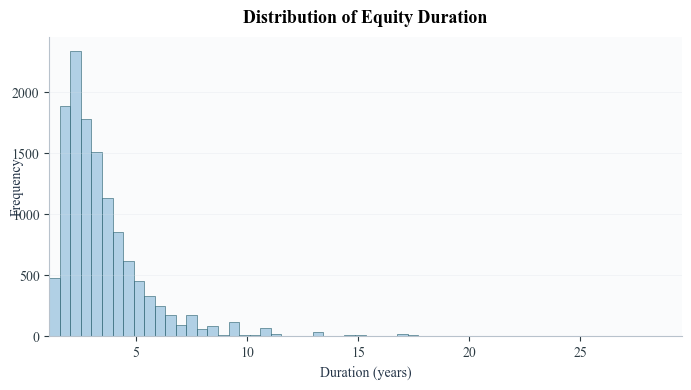


7. Duration vs BM: Robust Visual Diagnostic
Share with Duration_NP in [16, 20]: 0.41%


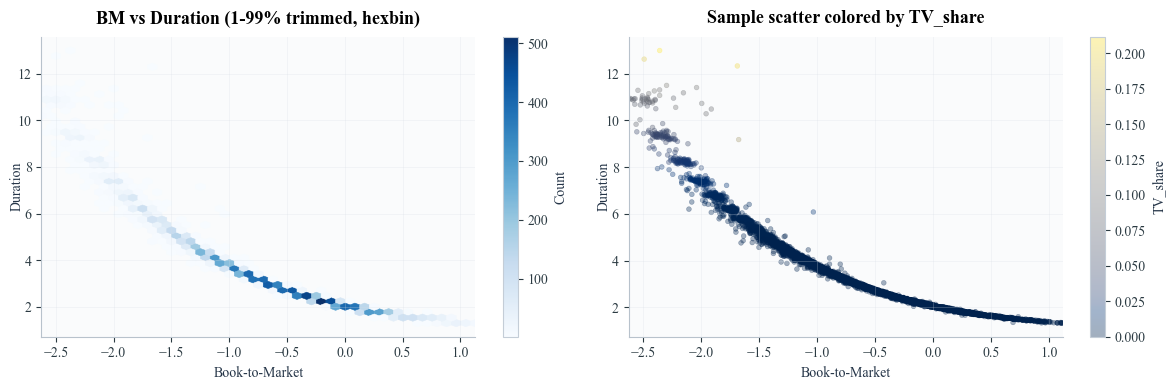

In [14]:
with pd.option_context("display.max_rows", 200, "display.max_columns", None, "display.width", 200):


    print("\n==============================")
    print("1. Basic Duration Distribution")
    print("==============================")

    print(state_panel["Duration_NP"].describe(percentiles=[0.01,0.05,0.5,0.95,0.99]))
    print("\nNaN share:", state_panel["Duration_NP"].isna().mean())

    d_tmp = pd.to_numeric(state_panel["Duration_NP"], errors="coerce")
    d_tmp = d_tmp[np.isfinite(d_tmp)]
    if len(d_tmp) > 0:
        print(f"Share Duration_NP > 100: {(d_tmp > 100).mean():.2%}")
        print(f"Share Duration_NP > 200: {(d_tmp > 200).mean():.2%}")

    if "discount_rate_NP" in state_panel.columns:
        dr = pd.to_numeric(state_panel["discount_rate_NP"], errors="coerce")
        dr_valid = dr.dropna()
        if len(dr_valid) > 0:
            near_gss = (dr_valid <= (beg_ss + 1e-3)).mean()
            near_low = (dr_valid <= 0.01).mean()
            print(f"Share discount_rate_NP <= beg_ss+1bp: {near_gss:.2%}")
            print(f"Share discount_rate_NP <= 1%: {near_low:.2%}")


    print("\n==============================")
    print("2. Correlations with Key Variables")
    print("==============================")

    vars_check = [
        "Duration_NP",
        "bm",
        "py",
        "ag",
        "beg",
        "roe",
        "csprof"
    ]

    corr = state_panel[vars_check].corr().round(3)
    display(corr)


    print("\n==============================")
    print("3. Duration by BM Quintiles")
    print("==============================")

    bm_test = state_panel.groupby(
        pd.qcut(state_panel["bm"], 5), observed=False
    )["Duration_NP"].mean()

    display(bm_test.to_frame("Duration_NP").round(4))


    print("\n==============================")
    print("4. Duration by Asset Growth Quintiles")
    print("==============================")

    growth_test = state_panel.groupby(
        pd.qcut(state_panel["ag"], 5), observed=False
    )["Duration_NP"].mean()

    display(growth_test.to_frame("Duration_NP").round(4))


    print("\n==============================")
    print("5. Duration by Payout Yield Quintiles")
    print("==============================")

    payout_test = state_panel.groupby(
        pd.qcut(state_panel["py"], 5), observed=False
    )["Duration_NP"].mean()

    display(payout_test.to_frame("Duration_NP").round(4))


    print("\n==============================")
    print("6. Duration Histogram")
    print("==============================")

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(
        state_panel["Duration_NP"].dropna(),
        bins=60,
        color=COLORS["blue_light"],
        edgecolor=COLORS["primary"],
        alpha=0.9,
    )
    ax.set_title("Distribution of Equity Duration")
    ax.set_xlabel("Duration (years)")
    ax.set_ylabel("Frequency")
    style_axes(ax)
    plt.tight_layout()
    plt.show()


    print("\n==============================")
    print("7. Duration vs BM: Robust Visual Diagnostic")
    print("==============================")

    plot_df = state_panel[["bm", "Duration_NP", "TV_share", "discount_rate_NP"]].dropna(subset=["bm", "Duration_NP"]).copy()

    if len(plot_df) == 0:
        print("No valid observations for bm vs Duration_NP plot.")
    else:
        # Report concentration in the visually suspicious low-duration band.
        band_share = plot_df["Duration_NP"].between(16, 20).mean()
        print(f"Share with Duration_NP in [16, 20]: {band_share:.2%}")

        # Trim only for visualization (core diagnostics still use full sample).
        bm_lo, bm_hi = plot_df["bm"].quantile([0.01, 0.99])
        dur_lo, dur_hi = plot_df["Duration_NP"].quantile([0.01, 0.99])
        plot_trim = plot_df[
            plot_df["bm"].between(bm_lo, bm_hi)
            & plot_df["Duration_NP"].between(dur_lo, dur_hi)
        ].copy()

        sample_n = min(6000, len(plot_trim))
        plot_sample = plot_trim.sample(n=sample_n, random_state=42) if sample_n > 0 else plot_trim

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        hb = axes[0].hexbin(
            plot_trim["bm"],
            plot_trim["Duration_NP"],
            gridsize=45,
            mincnt=1,
            cmap="Blues"
        )
        axes[0].set_title("BM vs Duration (1-99% trimmed, hexbin)")
        axes[0].set_xlabel("Book-to-Market")
        axes[0].set_ylabel("Duration")
        style_axes(axes[0], grid_axis="both")
        cbar_left = fig.colorbar(hb, ax=axes[0], label="Count")
        cbar_left.outline.set_edgecolor("#C4CDD7")

        if "TV_share" in plot_sample.columns and plot_sample["TV_share"].notna().any():
            sc = axes[1].scatter(
                plot_sample["bm"],
                plot_sample["Duration_NP"],
                c=plot_sample["TV_share"],
                s=12,
                alpha=0.35,
                cmap="cividis"
            )
            cbar_right = fig.colorbar(sc, ax=axes[1], label="TV_share")
            cbar_right.outline.set_edgecolor("#C4CDD7")
            axes[1].set_title("Sample scatter colored by TV_share")
        else:
            axes[1].scatter(
                plot_sample["bm"],
                plot_sample["Duration_NP"],
                s=12,
                alpha=0.35,
                color=COLORS["accent"],
            )
            axes[1].set_title("Sample scatter")

        axes[1].set_xlabel("Book-to-Market")
        axes[1].set_ylabel("Duration")
        style_axes(axes[1], grid_axis="both")

        plt.tight_layout()
        plt.show()


In [15]:

# ============================================================
# STEP 8: Diagnostic – Terminal Value Contribution
# NOTE: Dies ist NUR eine Diagnostik-Funktion.
#       Sie überschreibt NICHT state_panel["TV_share"],
#       die bereits korrekt in Step 6 (duration_from_solved_dr)
#       mit dem firm-year-spezifischen dr berechnet wurde.
# ============================================================

def compute_tv_share_diag(row, H=15, r=0.08):
    """
    Diagnostische TV_share-Berechnung mit fest kodierten Parametern.
    Schreibt NUR in 'TV_share_diag' – überschreibt NICHT 'TV_share'.

    NOTE: Abweichung vom Paper: nutzt hartkodierte r=0.08 und H=15
    statt der firm-year-spezifischen discount_rate_NP aus Step 6.
    Dient nur zur groben Plausibilitätsprüfung.
    """
    Phi_diag, const_diag, _ = list(var_params_by_year.values())[-1]
    x0 = row_to_state_vector(row)
    fstates = forecast_states_iterative(x0, H, Phi_diag, const_diag)
    path_df = pd.DataFrame(fstates, columns=var_states)
    path_df.insert(0, "horizon", np.arange(1, H + 1))

    be0 = pd.to_numeric(pd.Series([row.get("BE", np.nan)]), errors="coerce").iloc[0]
    if not (np.isfinite(be0) and be0 > 0):
        return np.nan
    be_prev = float(be0)
    po_list = []
    for h in range(H):
        beg_hat = float(path_df.loc[h, "beg"])
        csprof_hat = float(path_df.loc[h, "csprof"])
        po_hat = be_prev * (np.exp(csprof_hat) - np.exp(beg_hat))
        po_list.append(po_hat / be0)
        be_prev *= np.exp(beg_hat)
    path_df["PO_over_BE0"] = po_list

    beg_ss_last = float(np.linalg.solve(np.eye(len(var_states)) - Phi_diag, const_diag)[var_states.index("beg")])
    csprof_ss_last = float(np.linalg.solve(np.eye(len(var_states)) - Phi_diag, const_diag)[var_states.index("csprof")])
    po_be_ss_diag = np.exp(csprof_ss_last) - np.exp(beg_ss_last)
    be_scale_H = float(path_df.iloc[-1]["PO_over_BE0"] / po_be_ss_diag) if po_be_ss_diag != 0 else np.nan

    if (r - beg_ss_last) <= 1e-4:
        return np.nan
    ratio = np.exp(beg_ss_last - r)
    if ratio >= 1:
        return np.nan

    be_scale_H = np.prod([np.exp(float(path_df.loc[h, "beg"])) for h in range(H)])
    po_be0_Hp1 = be_scale_H * po_be_ss_diag
    PV_tail = np.exp(-r * (H + 1)) * po_be0_Hp1 / (1 - ratio)
    TV_H = PV_tail * np.exp(r * H)

    pv_sum = sum(po_list[h] * np.exp(-r * (h + 1)) for h in range(H))
    total_pv = pv_sum + np.exp(-r * H) * TV_H
    if not (np.isfinite(total_pv) and total_pv > 0):
        return np.nan
    return float(PV_tail / total_pv)


# WICHTIG: Schreibe NUR in TV_share_diag, NICHT in TV_share!
# TV_share wird korrekt aus duration_from_solved_dr() befüllt.
state_panel["TV_share_diag"] = state_panel.apply(compute_tv_share_diag, axis=1)

print("\n==============================")
print("Terminal Value Share (Diagnostik, H=15, r=0.08)")
print("Achtung: Nicht mit state_panel['TV_share'] verwechseln!")
print("==============================")
print(state_panel["TV_share_diag"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))
print("\nVergleich mit der korrekt berechneten TV_share:")
print(state_panel["TV_share"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))



Terminal Value Share (Diagnostik, H=15, r=0.08)
Achtung: Nicht mit state_panel['TV_share'] verwechseln!
count    12647.000000
mean         0.953927
std          0.021110
min          0.889768
1%           0.915891
5%           0.925835
50%          0.950658
95%          0.992595
99%          1.014079
max          1.183098
Name: TV_share_diag, dtype: float64

Vergleich mit der korrekt berechneten TV_share:
count    1.264700e+04
mean     5.636423e-03
std      3.779789e-02
min      2.367164e-27
1%       6.176428e-19
5%       7.109258e-13
50%      2.764191e-06
95%      1.457719e-02
99%      1.460111e-01
max      9.406639e-01
Name: TV_share, dtype: float64


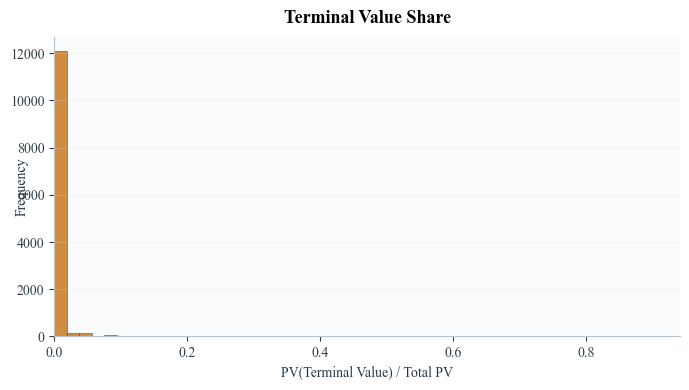

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(
    state_panel["TV_share"].dropna(),
    bins=50,
    color=COLORS["orange"],
    edgecolor=COLORS["primary"],
    alpha=0.85,
)
ax.set_title("Terminal Value Share")
ax.set_xlabel("PV(Terminal Value) / Total PV")
ax.set_ylabel("Frequency")
style_axes(ax)
plt.tight_layout()
plt.show()
